In [61]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import joblib



In [62]:
data = pd.read_csv('C:/Users/PAWAN/OneDrive/' \
'Desktop/Projects/employee_salary_prediction/' \
'data/Salary Data.csv')

data['Age'] = data['Age'].fillna(data['Age'].mean())

data['Years of Experience'] = data['Years of Experience'].fillna(
    data['Years of Experience'].mean()
)
data['Salary']= data['Salary'].fillna(data['Salary'].mean())


data.fillna({'Job Title':data['Job Title'].mode()[0],
             'Gender':data['Gender'].mode()[0],
             'Education Level':data['Education Level'].mode()[0]},
             inplace=True)

data.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [63]:
q1 = data['Salary'].quantile(0.25)
q3 = data['Salary'].quantile(0.75)
iqr = q3 - q1
print(q3,q1,iqr)
lower_limit = q1-1.5*iqr
upper_limit = q3+1.5*iqr
data
data = data[(data['Salary'] > lower_limit)&(data['Salary']<upper_limit)]


140000.0 55000.0 85000.0


In [64]:
le = LabelEncoder()

data['Education Level'],data['Gender'],data['Job Title'] = le.fit_transform(data['Education Level']),le.fit_transform(data['Gender']),le.fit_transform(data['Job Title'])
data
data.head(8)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0
5,29.0,1,0,81,2.0,55000.0
6,42.0,0,1,93,12.0,120000.0
7,31.0,1,0,104,4.0,80000.0


<Axes: xlabel='Salary', ylabel='Count'>

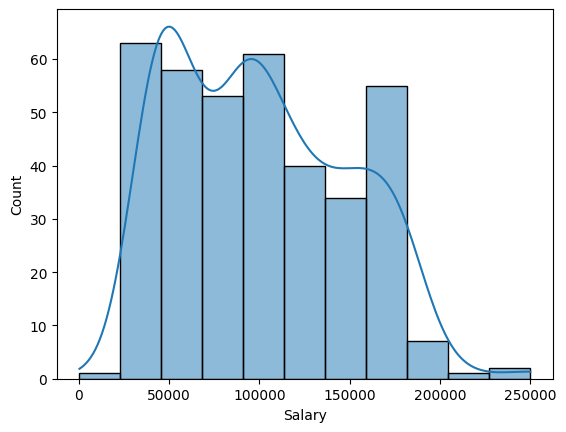

In [65]:
sns.histplot(data=data,x='Salary',kde=True)


<Axes: ylabel='Salary'>

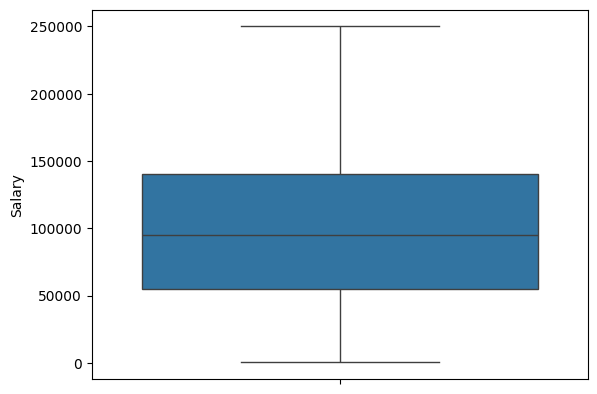

In [66]:
sns.boxplot(data = data,y = 'Salary')

In [67]:
x = data[['Age','Gender','Education Level','Job Title','Years of Experience']]
y = data[['Salary']]
y = np.log(y)
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
lr_model = LinearRegression()
lr_model.fit(xtrain,ytrain)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[0.04,0.03,0.12,0. ,0.03]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age','Gender','Education Level','Job Title','Years of Experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[9.49]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [69]:
ypred = lr_model.predict(xtest)
print(r2_score(ytest,ypred))
print(mean_absolute_error(ytest,ypred))
print(mean_squared_error(ytest,ypred))
print(ytest-ypred)



0.874205187153996
0.15322270585491718
0.034818056884201906
       Salary
167 -0.290786
33  -0.263043
15  -0.000281
316  0.058839
57  -0.163329
..        ...
94   0.307574
196 -0.130958
350 -0.004765
312 -0.087255
349  0.345156

[75 rows x 1 columns]


In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, x, y, cv=5, scoring='r2')
print(scores.mean())

0.7620212320398113
